## 1. Setup connection to jobs DB

In [14]:
from pathlib import Path

import duckdb
import pandas as pd

PROJECT_ROOT = Path.cwd()

# If the notebook starts inside the notebooks folder, move one level up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DB_PATH = PROJECT_ROOT / "db" / "jobs.duckdb"

print("Project root:", PROJECT_ROOT)
print("Database path:", DB_PATH)
print("Database exists:", DB_PATH.exists())

con = duckdb.connect(str(DB_PATH))
con.execute("SHOW TABLES").df()


#Conduct summary query of the dashboard -  view for career coach 
summary_query = """
SELECT
    COUNT(DISTINCT job_post_id) AS total_unique_job_postings,
    COUNT(DISTINCT category_name) AS total_categories,
    COUNT(DISTINCT company_name) AS total_companies,
    MIN(new_posting_date) AS earliest_posting_date,
    MAX(new_posting_date) AS latest_posting_date
FROM vw_career_coach_jobs;
"""
database_summary = con.execute(summary_query).df()
print("Summary Table:")
display(database_summary.head())


Project root: /home/kennywong/code/ntu-sctp/repos/dsai-module1-individual-project
Database path: /home/kennywong/code/ntu-sctp/repos/dsai-module1-individual-project/db/jobs.duckdb
Database exists: True
Summary Table:


,total_unique_job_postings,total_categories,total_companies,earliest_posting_date,latest_posting_date
0,1044597,43,53151,2023-02-24,2024-05-29


## 2. Query table results for analysis

In [ ]:
# This code section conducts analysis
# Limit query results to 10 for analysis
# Query - Top categories by job postings
query = """
SELECT
    category_name,
    COUNT(DISTINCT job_post_id) AS total_job_postings
FROM vw_career_coach_jobs
WHERE category_name IS NOT NULL
GROUP BY category_name
ORDER BY total_job_postings DESC
LIMIT 10;
"""
top_categories_by_postings = con.execute(query).df()


# Query - Top categories by vacancies
query = """
SELECT
    category_name,
    SUM(number_of_vacancies) AS total_vacancies
FROM vw_career_coach_jobs
WHERE category_name IS NOT NULL
GROUP BY category_name
ORDER BY total_vacancies DESC
LIMIT 10;
"""
top_categories_by_vacancies = con.execute(query).df()


# Query - Top categories by median avg salary
query = """
SELECT
    category_name,
    MEDIAN(salary_minimum) AS median_salary_minimum,
    MEDIAN(salary_maximum) AS median_salary_maximum,
    MEDIAN(average_salary) AS median_average_salary
FROM vw_career_coach_jobs
WHERE category_name IS NOT NULL
  AND average_salary IS NOT NULL
GROUP BY category_name
ORDER BY median_average_salary DESC
LIMIT 10;
"""
salary_by_category = con.execute(query).df()
salary_by_category[
    [
        "category_name",
        "median_salary_minimum",
        "median_salary_maximum",
        "median_average_salary"
    ]
]


# Query - Top categories by experience required
query = """
SELECT
    category_name,
    COUNT(DISTINCT job_post_id) AS total_job_postings,
    MEDIAN(minimum_years_experience) AS median_min_years_experience,
    AVG(minimum_years_experience) AS average_min_years_experience
FROM vw_career_coach_jobs
WHERE category_name IS NOT NULL
  AND minimum_years_experience IS NOT NULL
GROUP BY category_name
ORDER BY median_min_years_experience DESC, total_job_postings DESC
LIMIT 10;
"""
experience_by_category = con.execute(query).df()


# Query - Top entry level categories
query = """
SELECT
    category_name,
    COUNT(DISTINCT job_post_id) AS entry_level_job_postings,
    MEDIAN(average_salary) AS median_average_salary,
    MEDIAN(minimum_years_experience) AS median_min_years_experience
FROM vw_career_coach_jobs
WHERE category_name IS NOT NULL
  AND minimum_years_experience <= 1
GROUP BY category_name
ORDER BY entry_level_job_postings DESC
LIMIT 10;
"""
entry_level_friendly_categories = con.execute(query).df()


# 3. Develop insights

In [15]:

print("Demand by postings:")
display(top_categories_by_postings.head())

Demand by postings:


,category_name,total_job_postings
0,Information Technology,140866
1,Engineering,136372
2,Admin / Secretarial,117854
3,Customer Service,111785
4,Others,106101


## 3.1 Insight 1: Market demand by job postings
This table shows the job categories with the highest number of unique job postings.
For career coaches, this helps identify where jobseekers may find more visible market opportunities. A higher number of postings suggests stronger hiring activity in that category, although it does not guarantee that every jobseeker will be suitable for those roles.

Observation:
- The highest-volume categories are IT, Engineering, and Admin/Sec.
- These categories may be useful starting points when advising jobseekers who want broader market opportunities.

In [17]:
print("Demand by vacancies:")
display(top_categories_by_vacancies.head())

Demand by vacancies:


,category_name,total_vacancies
0,Customer Service,417980.0
1,Information Technology,316470.0
2,F&B,308650.0
3,Others,300759.0
4,Admin / Secretarial,295225.0


## 3.2 Insight 2: Market demand by vacancies
This table ranks job categories by total number of vacancies.

This gives a slightly different view from job postings. A category may have fewer postings but more vacancies if each posting is hiring multiple people.

For career coaches, vacancy count can help identify categories where employers may be looking to fill more roles overall.

In [18]:
print("Salary by category:")
display(salary_by_category.head())

Salary by category:


,category_name,median_salary_minimum,median_salary_maximum,median_average_salary
0,Information Technology,5000.0,8000.0,6500.0
1,Risk Management,4500.0,7000.0,6000.0
2,Banking and Finance,4500.0,6500.0,5500.0
3,Insurance,3500.0,5500.0,4750.0
4,Consulting,3500.0,6000.0,4725.0


## 3.3 Insight 3: Salary ranges by category
This table compares median salary values across job categories.

Median salary is used instead of average salary because salary data can contain outliers. A few very high or very low salaries can distort the average.

For career coaches, this helps support salary expectation discussions with jobseekers.

Observation:
- The categories with higher median average salaries are IT, Risk Mgmt, and Banking/Finance.
- These categories may offer stronger salary potential, but they may also require more specialised skills or e

In [19]:
print("Experience by category:")
display(experience_by_category.head())

Experience by category:


,category_name,total_job_postings,median_min_years_experience,average_min_years_experience
0,Information Technology,140866,3.0,3.814199
1,Engineering,136372,3.0,3.183843
2,Building and Construction,84034,3.0,3.690375
3,Banking and Finance,62000,3.0,3.443968
4,General Management,35397,3.0,3.528180


## 3.4 Insight 4: Experience requirements by category

This table compares the minimum years of experience required across job categories.

Categories with lower median experience requirements may be more accessible to fresh graduates, early-career jobseekers, or career switchers.

For career coaches, this helps identify categories that may have lower entry barriers.

Observation:
- The categories with lower median experience requirements are IT, Engineering, and Construction.
- These may be more suitable for jobseekers who are entering the labour market or switching fields.

In [16]:
print("Entry level friendly categories")
display(entry_level_friendly_categories.head())

Entry level friendly categories


,category_name,entry_level_job_postings,median_average_salary,median_min_years_experience
0,Admin / Secretarial,67727,2600.0,1.0
1,Customer Service,64780,2750.0,1.0
2,Others,50685,2850.0,1.0
3,Sales / Retail,50420,3100.0,1.0
4,Engineering,35601,3400.0,1.0


## 3.5 Insight 5: Entry-level friendly categories

This table focuses on job postings that require 0 to 1 year of experience.

This is useful for identifying categories that may be more suitable for fresh graduates and career switchers.

For career coaches, this can support practical discussions about where a jobseeker may have a more realistic starting point.

# 4: Career Opportunity Score

To make the analysis more data-driven, this section creates a simple scoring model for job categories.

The score combines three signals:

1. Demand: job postings and vacancies
2. Salary: median average salary
3. Accessibility: lower experience requirements and more entry-level postings

This is a prototype score, not a final recommendation engine. It is designed to help career coaches compare job categories more easily.

In [ ]:
# rerun connection to the DB

from pathlib import Path
import duckdb
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DB_PATH = PROJECT_ROOT / "db" / "jobs.duckdb"

con = duckdb.connect(str(DB_PATH))

In [ ]:
# create one summary row per category, only include categories with at least 100 job postings.

query = """
SELECT
    category_name,
    COUNT(DISTINCT job_post_id) AS total_job_postings,
    SUM(number_of_vacancies) AS total_vacancies,
    MEDIAN(average_salary) AS median_average_salary,
    MEDIAN(minimum_years_experience) AS median_min_years_experience,
    COUNT(DISTINCT CASE
        WHEN minimum_years_experience <= 1 THEN job_post_id
    END) AS entry_level_job_postings
FROM vw_career_coach_jobs
WHERE category_name IS NOT NULL
GROUP BY category_name
HAVING COUNT(DISTINCT job_post_id) >= 100
ORDER BY total_job_postings DESC;
"""

category_summary = con.execute(query).df()

category_summary["entry_level_share"] = (
    category_summary["entry_level_job_postings"] / category_summary["total_job_postings"]
)

display(category_summary.head(10))

,category_name,total_job_postings,total_vacancies,median_average_salary,median_min_years_experience,entry_level_job_postings,entry_level_share
0,Information Technology,140866,316470.0,6500.0,3.0,27868,0.197833
1,Engineering,136372,259883.0,4250.0,3.0,35601,0.261058
2,Admin / Secretarial,117854,295225.0,2900.0,1.0,67727,0.574669
3,Customer Service,111785,417980.0,3050.0,1.0,64780,0.579505
4,Others,106101,300759.0,3500.0,2.0,50685,0.477705
5,Sales / Retail,105067,285694.0,3550.0,2.0,50420,0.479884
6,Building and Construction,84034,180259.0,4000.0,3.0,13888,0.165266
7,Accounting / Auditing / Taxation,78648,164882.0,3600.0,2.0,25298,0.321661
8,F&B,73731,308650.0,3300.0,2.0,28502,0.386567
9,Logistics / Supply Chain,69193,178866.0,3250.0,2.0,29409,0.425029


In [23]:
score_df = category_summary.copy()

score_df = score_df.dropna(
    subset=[
        "total_job_postings",
        "total_vacancies",
        "median_average_salary",
        "median_min_years_experience",
        "entry_level_share"
    ]
)

# Demand score combines job postings and vacancies.
score_df["posting_score"] = score_df["total_job_postings"].rank(pct=True) * 100
score_df["vacancy_score"] = score_df["total_vacancies"].rank(pct=True) * 100
score_df["demand_score"] = (
    score_df["posting_score"] * 0.5
    + score_df["vacancy_score"] * 0.5
)

# Salary score rewards higher median salary.
score_df["salary_score"] = score_df["median_average_salary"].rank(pct=True) * 100

# Accessibility score rewards lower experience requirements and higher entry-level share.
score_df["low_experience_score"] = (
    score_df["median_min_years_experience"].rank(pct=True, ascending=False) * 100
)

score_df["entry_level_score"] = score_df["entry_level_share"].rank(pct=True) * 100

score_df["accessibility_score"] = (
    score_df["low_experience_score"] * 0.5
    + score_df["entry_level_score"] * 0.5
)

# Final opportunity score.
score_df["opportunity_score"] = (
    score_df["demand_score"] * 0.4
    + score_df["salary_score"] * 0.3
    + score_df["accessibility_score"] * 0.3
)

opportunity_score = score_df.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

display(
    opportunity_score[
        [
            "category_name",
            "total_job_postings",
            "total_vacancies",
            "median_average_salary",
            "median_min_years_experience",
            "entry_level_share",
            "demand_score",
            "salary_score",
            "accessibility_score",
            "opportunity_score"
        ]
    ].head(10)
)

,category_name,total_job_postings,total_vacancies,median_average_salary,median_min_years_experience,entry_level_share,demand_score,salary_score,accessibility_score,opportunity_score
0,Information Technology,140866,316470.0,6500.0,3.0,0.197833,98.837209,100.000000,8.720930,72.151163
1,Customer Service,111785,417980.0,3050.0,1.0,0.579505,96.511628,13.953488,96.511628,71.744186
2,Admin / Secretarial,117854,295225.0,2900.0,1.0,0.574669,93.023256,8.139535,95.348837,68.255814
3,Consulting,38961,180228.0,4725.0,2.0,0.366726,68.604651,90.697674,43.604651,67.732558
4,Sales / Retail,105067,285694.0,3550.0,2.0,0.479884,88.372093,39.534884,65.697674,66.918605
5,Engineering,136372,259883.0,4250.0,3.0,0.261058,91.860465,86.046512,12.209302,66.220930
6,Others,106101,300759.0,3500.0,2.0,0.477705,91.860465,32.558140,64.534884,65.872093
7,Sciences / Laboratory / R&D,19753,32357.0,4500.0,2.0,0.488938,41.860465,88.372093,68.023256,63.662791
8,Banking and Finance,62000,133458.0,5500.0,3.0,0.335887,72.093023,95.348837,18.023256,62.848837
9,Education and Training,44877,222040.0,3250.0,1.0,0.544421,73.255814,19.767442,91.860465,62.790698


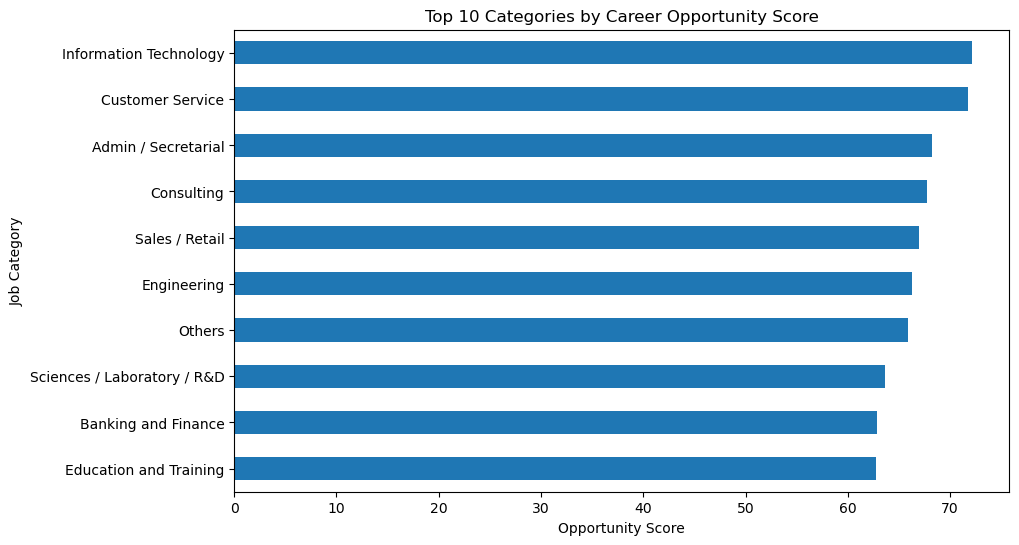

In [24]:
top_10_opportunity = opportunity_score.head(10)

ax = top_10_opportunity.plot(
    kind="barh",
    x="category_name",
    y="opportunity_score",
    legend=False,
    figsize=(10, 6)
)

ax.set_title("Top 10 Categories by Career Opportunity Score")
ax.set_xlabel("Opportunity Score")
ax.set_ylabel("Job Category")
ax.invert_yaxis()

## Insight

The Career Opportunity Score is a simple prototype ranking. It combines demand, salary, and accessibility into one score so that career coaches can compare job categories more easily.

A high score does not mean that a category is suitable for every jobseeker. It means the category performs relatively well across the selected labour-market signals.

Career coaches should still consider the jobseeker's background, skills, interests, and constraints before making recommendations.